# Start here: one choice, two columns

A release controller has evidence, but evidence alone cannot tell it whether to act. It also needs to know what the consequences are worth. The first experiment separates those two questions, then makes a choice small enough to check by hand.

The laboratory follows all 27 chapters of *The Mathematics of AI Agents*. Every chapter has a notebook, a skill and a documented input shape. The notebooks teach the calculation; the skills let an assistant apply the same computation to a new case. The master skill helps select the method. Neither format supplies information that the inputs do not contain.

This orientation gives one successful run. It also shows how to find the changed-assumption experiment, the separate solutions, and the local reading guide.

- Prepare the notebook and inspect its inputs.
- Calculate expected utility and reverse the choice.
- Find a chapter or assistant skill.
- Record what a result actually establishes.

## Technical Requirements

For notebooks, use Python 3.11 or later and the dependencies installed by the launcher. For the chapter calculations without notebooks, Python 3.10 or later is enough. Keep the complete extracted folder together. No API key or model subscription is required.

On Mac, double-click **Open Laboratory.command**. Choose **Install notebook tools** once, then **Open Jupyter notebooks**. The first installation may need a network connection to obtain packages. Later examples run locally. If you want to read before installing anything, open `guide/index.html`.

In Jupyter, open this notebook and choose **Run → Run All Cells**. Each code cell should finish without a traceback. The cell below locates the complete bundle and imports its computations.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


## Calculate before choosing

Suppose release succeeds with probability 0.8. Success is worth 10 utility units; failure is worth -30. Attempting release costs 1 unit. Declining has utility zero. These values are stipulated for this example, not measured facts or an objective valuation.

The release utility is `0.8 × 10 + 0.2 × (-30) - 1 = 1`. Declining has utility zero, so the declared rule prefers release. The probability is a belief about the outcome; the utilities express how much the outcome matters. Keep those columns separate.

The next cell performs that same calculation. The labels identify actions; the probabilities in each row must sum to one.

Chapter 6: expected-utility
Should this controller release, request review, or abstain?
Evidence: constructed teaching example

Calculated quantities:
{
  "selected_action": "release",
  "expected_utility": 1.0,
  "break_even_first_utility": 8.75
}

Interpretation:
The selected action maximizes the declared expected utility, including any abstention row.

Assumptions:
- Utilities and probabilities are supplied judgments.
- One decision, mutually exclusive outcomes per action.

Limitations:
- No objective valuation or calibrated probability is inferred.

Execution: completed locally; constructed inputs are not deployment measurements.


Matplotlib is building the font cache; this may take a moment.


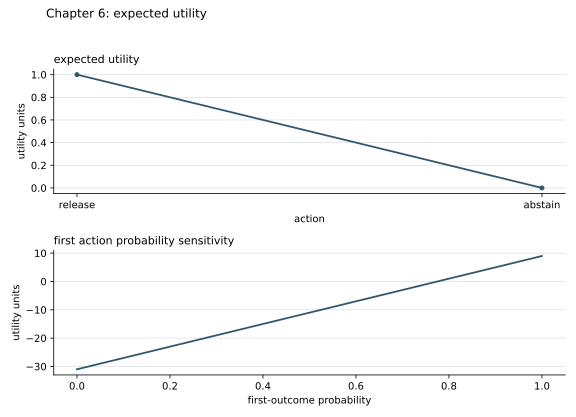

In [2]:
choice = {"actions": [
    {"name": "release", "probabilities": [0.8, 0.2], "utilities": [10, -30], "cost": 1},
    {"name": "abstain", "probabilities": [1.0], "utilities": [0], "cost": 0}
]}
first = analyze(6, choice)
first['evidence_kind'] = 'constructed teaching example'
print(report_text(first))
assert first['result']['metrics']['selected_action'] == 'release'
display(SVG(figure_svg(first)))

**Figure 0.1:** The declared actions and their probability sensitivity. A higher value ranks an action under these utilities; it does not authorize release.

## Change what you know

Now lower the release-success probability to 0.6 while keeping the same outcome values and cost. Before running the next cell, calculate the new expected utility. It is `6 - 12 - 1 = -7`, so the preferred action should change to abstention.

The code copies the input before changing it. Your original example remains available for comparison.

In [3]:
import copy
less_certain = copy.deepcopy(choice)
less_certain['actions'][0]['probabilities'] = [0.6, 0.4]
second = analyze(6, less_certain)
second['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(second))
assert second['result']['metrics']['selected_action'] == 'abstain' 

Chapter 6: expected-utility
Should this controller release, request review, or abstain?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "selected_action": "abstain",
  "expected_utility": 0.0,
  "break_even_first_utility": 21.66666667
}

Interpretation:
The selected action maximizes the declared expected utility, including any abstention row.

Assumptions:
- Utilities and probabilities are supplied judgments.
- One decision, mutually exclusive outcomes per action.

Limitations:
- No objective valuation or calibrated probability is inferred.

Execution: completed locally; constructed inputs are not deployment measurements.


## Find the method you need

Chapter notebooks are numbered in reading order. The chapter skill listed at the end of each notebook takes a documented JSON object and returns the same calculation. Use `data/examples/ch06.json` as a valid shape, then save your own copy with your own values.

The master skill, `math-ai-agents`, routes by mathematical purpose. A request about a failing sequence may need a trajectory model, a tool-effect trace or an evaluation of observed runs. Those are different inputs and different conclusions. The small helper below offers suggestions; an assistant must still check the requested outcome and assumptions.

In [4]:
from math_ai_agents.routing import suggest
print(json.dumps(suggest('Compare the retry with verification after a lost acknowledgement'), indent=2))

{
  "status": "suggestion",
  "chapters": [
    17
  ],
  "reason": "Phrase-based suggestions; the assistant must verify the intended estimand and input contract.",
  "matches": [
    {
      "chapter": 17,
      "phrases": [
        "lost acknowledgement",
        "retry"
      ]
    }
  ]
}


## Continue through the book

Start with Chapters 1 through 5 to distinguish model capability, measurement and assembled agent behavior. Chapters 6 through 13 develop decisions, beliefs, planning and learning. Chapters 14 through 18 study models, memory, computation, tool effects and interfaces. Chapters 19 through 21 study counterparties and institutions. Chapters 22 through 27 separate authority, security, measured capability, improvement and human delegation.

For a complete constructed controller, open `28-document-release-capstone.ipynb`. For hand calculations without a notebook, read the standalone workbook. Answers remain in the separate solutions so you can attempt the questions first.

## Summary

You calculated one action's value, changed a belief and saw the choice reverse. Nothing in that calculation established a probability estimate, chose a utility scale or granted permission. The rest of the laboratory keeps that separation visible as the system becomes larger. A useful result names its inputs, computes what follows from them, and stops where their warrant stops.